In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from currency_converter import CurrencyConverter
from datetime import date

## Read Data

In [3]:
# https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
li_small_accounts_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/LI-Small_accounts.csv')
li_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930
...,...,...,...,...,...
712683,China Bank #42,692,80346A5F0,800D080A0,Corporation #40025
712684,First Bank of Watertown,118699,80B802A70,8005319C0,Partnership #14803
712685,Bank of Lincoln,213123,80847BE70,800453480,Partnership #11893
712686,Hilltop Credit Union,18747,803A36270,8003B5120,Partnership #6726


In [4]:
li_small_trans_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/LI-Small_trans.csv')
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,US Dollar,3.195403e+06,US Dollar,Reinvestment,0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,US Dollar,1.858960e+03,US Dollar,Reinvestment,0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,US Dollar,5.925710e+05,US Dollar,Cheque,0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,US Dollar,1.232000e+01,US Dollar,Reinvestment,0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,US Dollar,2.941560e+03,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,Bitcoin,3.346900e-02,Bitcoin,Bitcoin,0
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,Bitcoin,1.313000e-03,Bitcoin,Bitcoin,0
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,Bitcoin,1.305800e-02,Bitcoin,Bitcoin,0
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,Bitcoin,4.145370e-01,Bitcoin,Bitcoin,0


In [5]:
hi_small_accounts_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_accounts.csv')
hi_small_accounts_df

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889
...,...,...,...,...,...
518576,France Bank #33,3881,807886B70,80062D160,Sole Proprietorship #22257
518577,National Bank of Topeka,333423,81314C870,800F40230,Sole Proprietorship #4995
518578,Plandor Trust Bank,1467,804ED2270,800CAC4C0,Sole Proprietorship #35326
518579,Sappo Bancorp,2843,801727270,800EFCB40,Sole Proprietorship #3522


In [6]:
hi_small_trans_df = pd.read_csv('C:/Users/caleb/Downloads/ibm_aml/HI-Small_trans.csv')
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0


## Summarize Data

In [7]:
li_small_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712688 entries, 0 to 712687
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       712688 non-null  object
 1   Bank ID         712688 non-null  int64 
 2   Account Number  712688 non-null  object
 3   Entity ID       712688 non-null  object
 4   Entity Name     712688 non-null  object
dtypes: int64(1), object(4)
memory usage: 27.2+ MB


In [8]:
li_small_trans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           6924049 non-null  object 
 1   From Bank           6924049 non-null  int64  
 2   Account             6924049 non-null  object 
 3   To Bank             6924049 non-null  int64  
 4   Account.1           6924049 non-null  object 
 5   Amount Received     6924049 non-null  float64
 6   Receiving Currency  6924049 non-null  object 
 7   Amount Paid         6924049 non-null  float64
 8   Payment Currency    6924049 non-null  object 
 9   Payment Format      6924049 non-null  object 
 10  Is Laundering       6924049 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 581.1+ MB


In [9]:
hi_small_accounts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518581 entries, 0 to 518580
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Bank Name       518581 non-null  object
 1   Bank ID         518581 non-null  int64 
 2   Account Number  518581 non-null  object
 3   Entity ID       518581 non-null  object
 4   Entity Name     518581 non-null  object
dtypes: int64(1), object(4)
memory usage: 19.8+ MB


In [10]:
hi_small_trans_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Timestamp           5078345 non-null  object 
 1   From Bank           5078345 non-null  int64  
 2   Account             5078345 non-null  object 
 3   To Bank             5078345 non-null  int64  
 4   Account.1           5078345 non-null  object 
 5   Amount Received     5078345 non-null  float64
 6   Receiving Currency  5078345 non-null  object 
 7   Amount Paid         5078345 non-null  float64
 8   Payment Currency    5078345 non-null  object 
 9   Payment Format      5078345 non-null  object 
 10  Is Laundering       5078345 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


There are no null values in any of the datasets

The account dataframes show details about accounts, what bank the account belongs to, and the business entity that owns the bank account

The transactions show different types of payments between accounts

The reasoning for the datasets being split into two groups is as follows:

- Group HI has a relatively higher illicit ratio (more laundering).
- Group LI has a relatively lower illicit ratio (less laundering).

In [11]:
len(hi_small_accounts_df['Account Number'].unique())

518573

In [12]:
hi_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06,5.078345e+06
mean,4.573057e+04,6.574456e+04,5.988726e+06,4.509273e+06,1.019427e-03
std,8.176562e+04,8.409299e+04,1.037183e+09,8.697728e+08,3.191219e-02
min,1.000000e+00,1.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,1.190000e+02,4.259000e+03,1.833700e+02,1.844800e+02,0.000000e+00
50%,9.679000e+03,2.156800e+04,1.411010e+03,1.414540e+03,0.000000e+00
75%,2.862800e+04,1.223320e+05,1.234627e+04,1.229784e+04,0.000000e+00
max,3.563030e+05,3.562940e+05,1.046302e+12,1.046302e+12,1.000000e+00


In [13]:
li_small_trans_df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,5.938718e+04,8.441702e+04,6.324067e+06,4.676036e+06,5.148722e-04
std,9.051700e+04,9.064562e+04,2.105371e+09,1.544099e+09,2.268495e-02
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06,0.000000e+00
25%,2.190000e+02,1.125500e+04,1.742100e+02,1.753800e+02,0.000000e+00
50%,1.419500e+04,2.964000e+04,1.397620e+03,1.399440e+03,0.000000e+00
75%,1.106820e+05,1.480400e+05,1.229633e+04,1.222687e+04,0.000000e+00
max,3.769670e+05,3.769670e+05,3.644854e+12,3.644854e+12,1.000000e+00


In [14]:
li_small_trans_df.sort_values(by="Amount Paid").tail(5)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
510834,2022/09/01 01:46,123800,808B7F870,119699,809CE4D70,3.871530e+11,Rupee,3.871530e+11,Rupee,Cash,0
1334434,2022/09/01 19:57,215278,8068972A0,123135,8145F9B50,6.653123e+11,Yen,6.653123e+11,Yen,Cheque,0
6883964,2022/09/10 20:14,25552,80ABDDA10,23494,80ABDF080,6.779867e+11,Rupee,6.779867e+11,Rupee,ACH,0
3007683,2022/09/04 13:44,123260,80A274810,2,80A286620,8.623400e+11,Rupee,8.623400e+11,Rupee,ACH,0
2525880,2022/09/02 23:06,11047,8018B08B0,22297,8157483D0,3.644854e+12,Yen,3.644854e+12,Yen,Cheque,0


In [15]:
li_small_trans_df['Payment Currency'].unique()

array(['US Dollar', 'Euro', 'Bitcoin', 'Yuan', 'Yen', 'UK Pound',
       'Brazil Real', 'Australian Dollar', 'Rupee', 'Ruble',
       'Canadian Dollar', 'Mexican Peso', 'Swiss Franc', 'Shekel',
       'Saudi Riyal'], dtype=object)

## Preprocess the Amounts for Currency Conversion

In [16]:
li_small_trans_df[li_small_trans_df['Receiving Currency'] != li_small_trans_df['Payment Currency']]

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
2770,2022/09/01 00:12,394,80056EDE0,394,80056EDE0,47.610000,Euro,55.79,US Dollar,ACH,0
8081,2022/09/01 00:28,11701,800C95BF0,11701,800C95BF0,954.620000,Yuan,142.53,US Dollar,ACH,0
10451,2022/09/01 00:18,22481,80105E630,22481,80105E630,16930.030000,Yen,160.63,US Dollar,ACH,0
12948,2022/09/01 00:17,1439,8014545C0,1439,8014545C0,14.520000,UK Pound,18.76,US Dollar,ACH,0
13799,2022/09/01 00:02,20,8015D68E0,20,8015D68E0,37.000000,Euro,43.35,US Dollar,ACH,0
...,...,...,...,...,...,...,...,...,...,...,...
6924007,2022/09/10 23:57,9096,80356BD61,9096,80356BD60,0.000005,Bitcoin,0.39,Yuan,ACH,0
6924009,2022/09/10 23:30,9096,80356BD61,9096,80356BD60,0.000007,Bitcoin,0.55,Yuan,ACH,0
6924019,2022/09/10 23:38,13474,803A93631,13474,803A93630,0.000007,Bitcoin,0.08,US Dollar,ACH,0
6924021,2022/09/10 23:31,13474,803A93631,13474,803A93630,0.000020,Bitcoin,0.23,US Dollar,ACH,0


We want to maintain the Payment/Receiving Currency, since it indicates if a transaction was sent/received in the same country. We should scale all the currencys to a single currency like Dollar to make them comparable.

In [17]:
# 1 of XYZ currency to USD as of 9/1/2022 via https://www.exchangerates.org.uk/historical/.../01_09_2022
usd_to_usd = 1
euro_to_usd = 0.9945
btc_to_usd = 20050.50 # Opening BTC price
yuan_to_usd =  0.1446
yen_to_usd = 0.0071
pound_to_usd = 1.154
brazil_to_usd = 0.1907
aus_to_usd = 0.6789
rupee_to_usd =  0.0125 # Assuming Indian Rupee
ruble_to_usd = 0.0166
canadian_to_usd = 0.7601
peso_to_usd = 0.0495
swiss_to_usd = 1.0184
shekel_to_usd = 0.2943
riyal_to_usd = 0.266

In [18]:
currency_map = {
    'US Dollar': usd_to_usd,
    'Euro': euro_to_usd, 
    'Bitcoin': btc_to_usd, 
    'Yuan': yuan_to_usd, 
    'Yen': yen_to_usd, 
    'UK Pound': pound_to_usd,
    'Brazil Real': brazil_to_usd,
    'Australian Dollar': aus_to_usd, 
    'Rupee': rupee_to_usd, 
    'Ruble': ruble_to_usd,
    'Canadian Dollar': canadian_to_usd, 
    'Mexican Peso': peso_to_usd, 
    'Swiss Franc': swiss_to_usd, 
    'Shekel': shekel_to_usd,
    'Saudi Riyal': riyal_to_usd,
}

In [19]:
li_small_trans_df['Amount_Received_USD'] = li_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
li_small_trans_df['Amount_Paid_USD'] = li_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

In [20]:
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,3.195403e+06,US Dollar,3.195403e+06,US Dollar,Reinvestment,0,3.195403e+06,3.195403e+06
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,1.858960e+03,US Dollar,1.858960e+03,US Dollar,Reinvestment,0,1.858960e+03,1.858960e+03
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,5.925710e+05,US Dollar,5.925710e+05,US Dollar,Cheque,0,5.925710e+05,5.925710e+05
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,1.232000e+01,US Dollar,1.232000e+01,US Dollar,Reinvestment,0,1.232000e+01,1.232000e+01
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,2.941560e+03,US Dollar,2.941560e+03,US Dollar,Reinvestment,0,2.941560e+03,2.941560e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,3.346900e-02,Bitcoin,3.346900e-02,Bitcoin,Bitcoin,0,6.710702e+02,6.710702e+02
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,1.313000e-03,Bitcoin,1.313000e-03,Bitcoin,Bitcoin,0,2.632631e+01,2.632631e+01
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,1.305800e-02,Bitcoin,1.305800e-02,Bitcoin,Bitcoin,0,2.618194e+02,2.618194e+02
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,4.145370e-01,Bitcoin,4.145370e-01,Bitcoin,Bitcoin,0,8.311674e+03,8.311674e+03


In [21]:
hi_small_trans_df['Amount_Received_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Received'] * currency_map[row['Receiving Currency']], axis=1)
hi_small_trans_df['Amount_Paid_USD'] = hi_small_trans_df.apply(lambda row: row['Amount Paid'] * currency_map[row['Payment Currency']], axis=1)

In [22]:
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,US Dollar,3697.340000,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,US Dollar,14675.570000,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,US Dollar,2806.970000,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,US Dollar,36682.970000,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,Bitcoin,0.154978,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,Bitcoin,0.108128,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,Bitcoin,0.004988,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,Bitcoin,0.038417,Bitcoin,Bitcoin,0,770.280058,770.280058


In [23]:
hi_small_trans_df = hi_small_trans_df.drop(columns=['Amount Paid', 'Amount Received'])
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,US Dollar,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,US Dollar,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,US Dollar,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,US Dollar,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,US Dollar,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,770.280058,770.280058


In [24]:
li_small_trans_df = li_small_trans_df.drop(columns=['Amount Paid', 'Amount Received'])
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,US Dollar,US Dollar,Reinvestment,0,3.195403e+06,3.195403e+06
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,US Dollar,US Dollar,Reinvestment,0,1.858960e+03,1.858960e+03
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,US Dollar,US Dollar,Cheque,0,5.925710e+05,5.925710e+05
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,US Dollar,US Dollar,Reinvestment,0,1.232000e+01,1.232000e+01
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,US Dollar,US Dollar,Reinvestment,0,2.941560e+03,2.941560e+03
...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,Bitcoin,Bitcoin,Bitcoin,0,6.710702e+02,6.710702e+02
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,Bitcoin,Bitcoin,Bitcoin,0,2.632631e+01,2.632631e+01
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,Bitcoin,Bitcoin,Bitcoin,0,2.618194e+02,2.618194e+02
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,Bitcoin,Bitcoin,Bitcoin,0,8.311674e+03,8.311674e+03


In [25]:
li_small_trans_df['Amount_Paid_USD'].min(), li_small_trans_df['Amount_Paid_USD'].max() 

(np.float64(7.1e-05), np.float64(34581154295.51))

## Preprocess the Categorical Features

In [83]:
li_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,US Dollar,US Dollar,Reinvestment,0,3.195403e+06,3.195403e+06
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,US Dollar,US Dollar,Reinvestment,0,1.858960e+03,1.858960e+03
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,US Dollar,US Dollar,Cheque,0,5.925710e+05,5.925710e+05
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,US Dollar,US Dollar,Reinvestment,0,1.232000e+01,1.232000e+01
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,US Dollar,US Dollar,Reinvestment,0,2.941560e+03,2.941560e+03
...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,Bitcoin,Bitcoin,Bitcoin,0,6.710702e+02,6.710702e+02
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,Bitcoin,Bitcoin,Bitcoin,0,2.632631e+01,2.632631e+01
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,Bitcoin,Bitcoin,Bitcoin,0,2.618194e+02,2.618194e+02
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,Bitcoin,Bitcoin,Bitcoin,0,8.311674e+03,8.311674e+03


In [84]:
len(li_small_trans_df['Payment Currency'].unique())

15

In [85]:
len(li_small_trans_df['Payment Format'].unique())

7

In [ ]:
# I need to convert the Receiving Currency, Payment Currency, Payment Format into numeric encodings. I will use One Hot encoding since there is no order and not too many unique values

In [88]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Receiving Currency',
    'Payment Currency',
    'Payment Format',
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_hot_encoded = encoder.fit_transform(li_small_trans_df[categorical_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_features))
li_small_trans_cleaned_df = pd.concat([li_small_trans_df.drop(categorical_features, axis=1), one_hot_df], axis=1)
li_small_trans_cleaned_df

,Timestamp,From Bank,Account,To Bank,Account.1,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:08,11,8000ECA90,11,8000ECA90,0,3.195403e+06,3.195403e+06,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:21,3402,80021DAD0,3402,80021DAD0,0,1.858960e+03,1.858960e+03,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2022/09/01 00:00,11,8000ECA90,1120,8006AA910,0,5.925710e+05,5.925710e+05,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2022/09/01 00:16,3814,8006AD080,3814,8006AD080,0,1.232000e+01,1.232000e+01,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:00,20,8006AD530,20,8006AD530,0,2.941560e+03,2.941560e+03,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6924044,2022/09/10 23:39,71696,81B2518F1,71528,81C0482E1,0,6.710702e+02,6.710702e+02,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6924045,2022/09/10 23:48,271241,81B567481,173457,81C0DA751,0,2.632631e+01,2.632631e+01,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6924046,2022/09/10 23:50,271241,81B567481,173457,81C0DA751,0,2.618194e+02,2.618194e+02,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6924047,2022/09/10 23:57,170558,81A2206B1,275798,81C1D5CA1,0,8.311674e+03,8.311674e+03,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [89]:
one_hot_encoded = encoder.transform(hi_small_trans_df[categorical_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_features))
hi_small_trans_cleaned_df = pd.concat([hi_small_trans_df.drop(categorical_features, axis=1), one_hot_df], axis=1)
hi_small_trans_cleaned_df

,Timestamp,From Bank,Account,To Bank,Account.1,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Receiving Currency_Australian Dollar,Receiving Currency_Bitcoin,...,Payment Currency_US Dollar,Payment Currency_Yen,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,0,3697.340000,3697.340000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0,0.010000,0.010000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,0,14675.570000,14675.570000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,0,2806.970000,2806.970000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,0,36682.970000,36682.970000,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0,3107.386389,3107.386389,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0,2168.020464,2168.020464,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0,100.011894,100.011894,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0,770.280058,770.280058,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Check for Inifinite Values and Duplicates

In [26]:
hi_small_accounts_num_df = hi_small_accounts_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = hi_small_accounts_df[np.isinf(hi_small_accounts_num_df).any(axis=1)]
rows_with_inf

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [27]:
li_small_accounts_num_df = li_small_accounts_df.select_dtypes(include=[np.number])
# Find rows where ANY column has an infinite value
rows_with_inf = li_small_accounts_df[np.isinf(li_small_accounts_num_df).any(axis=1)]
rows_with_inf

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [28]:
hi_small_trans_num_df = hi_small_trans_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = hi_small_trans_df[np.isinf(hi_small_trans_num_df).any(axis=1)]
rows_with_inf

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD


In [29]:
li_small_trans_num_df = li_small_trans_df.select_dtypes(include=[np.number])

# Find rows where ANY column has an infinite value
rows_with_inf = li_small_trans_df[np.isinf(li_small_trans_num_df).any(axis=1)]
rows_with_inf

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD


There are no inf values

In [30]:
hi_small_accounts_df[hi_small_accounts_df.duplicated(keep=False)]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [31]:
li_small_accounts_df[li_small_accounts_df.duplicated(keep=False)]

,Bank Name,Bank ID,Account Number,Entity ID,Entity Name


In [32]:
hi_small_trans_df[hi_small_trans_df.duplicated(keep=False)]

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
863293,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,Bitcoin,Euro,ACH,0,0.160404,0.079560
863294,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,Bitcoin,Bitcoin,Bitcoin,0,0.160404,0.160404
863295,2022/09/01 16:20,12004,800C927C1,12004,800C927C0,Bitcoin,Euro,ACH,0,0.160404,0.079560
863296,2022/09/01 16:20,12004,800C927C1,220,813D8C1E1,Bitcoin,Bitcoin,Bitcoin,0,0.160404,0.160404
3684003,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,Bitcoin,Bitcoin,Bitcoin,0,0.060152,0.060152
3684005,2022/09/07 21:25,29992,8099A29B1,220,813725AE1,Bitcoin,Bitcoin,Bitcoin,0,0.060152,0.060152
4166784,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,Bitcoin,US Dollar,ACH,0,0.040101,0.020000
4166785,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,Bitcoin,Bitcoin,Bitcoin,0,0.040101,0.040101
4166786,2022/09/08 21:05,113779,811144AB1,113779,811144AB0,Bitcoin,US Dollar,ACH,0,0.040101,0.020000
4166787,2022/09/08 21:05,113779,811144AB1,53744,813C777F1,Bitcoin,Bitcoin,Bitcoin,0,0.040101,0.040101


In [33]:
li_small_trans_df[li_small_trans_df.duplicated(keep=False)]

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
676694,2022/09/01 05:03,21260,8085A09D1,72146,81AB967E1,Bitcoin,Bitcoin,Bitcoin,0,0.020050,0.020050
676696,2022/09/01 05:03,21260,8085A09D1,72146,81AB967E1,Bitcoin,Bitcoin,Bitcoin,0,0.020050,0.020050
790828,2022/09/01 07:44,231616,814E45511,171546,81B324AC1,Bitcoin,Bitcoin,Bitcoin,0,0.020050,0.020050
790830,2022/09/01 07:44,231616,814E45511,171546,81B324AC1,Bitcoin,Bitcoin,Bitcoin,0,0.020050,0.020050
2027614,2022/09/02 11:09,28335,804B468F1,171669,81BBCDAB1,Bitcoin,Bitcoin,Bitcoin,0,0.140353,0.140353
2027616,2022/09/02 11:09,28335,804B468F1,171669,81BBCDAB1,Bitcoin,Bitcoin,Bitcoin,0,0.140353,0.140353
3482551,2022/09/05 12:44,22661,80D016C81,269294,81A245E81,Bitcoin,Bitcoin,Bitcoin,0,0.100253,0.100253
3482553,2022/09/05 12:44,22661,80D016C81,269294,81A245E81,Bitcoin,Bitcoin,Bitcoin,0,0.100253,0.100253
4180129,2022/09/06 14:16,19970,804E44F11,169489,8197DC971,Bitcoin,Bitcoin,Bitcoin,0,0.020050,0.020050
4180131,2022/09/06 14:16,19970,804E44F11,169489,8197DC971,Bitcoin,Bitcoin,Bitcoin,0,0.020050,0.020050


The identified duplicates are duplicate transactions. Since this just means the same amount is sent between the same accounts, I will leave these as valid samples.

## Boxplots

<Axes: >

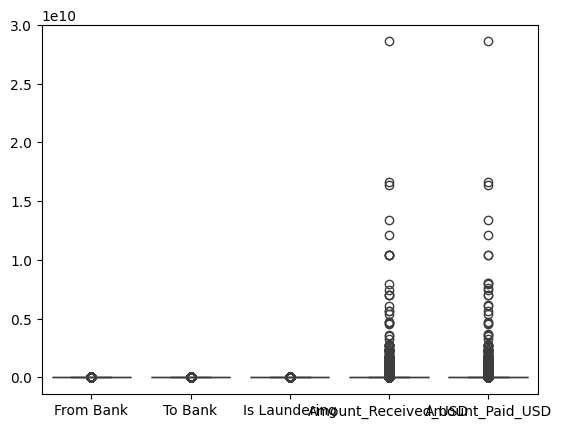

In [34]:
sns.boxplot(hi_small_trans_df)

<Axes: >

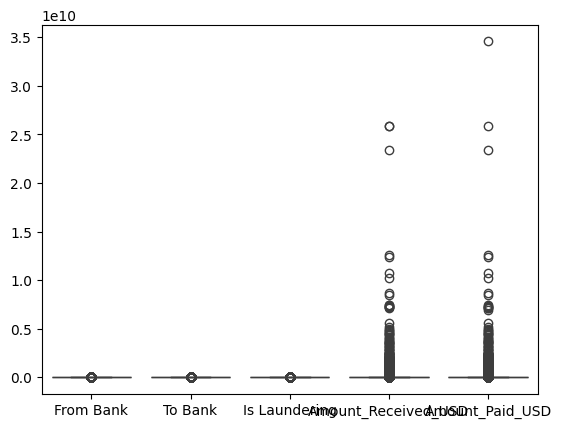

In [35]:
sns.boxplot(li_small_trans_df)

## Correlations

In [102]:
def get_highest_correlations(df, n_pairs=10):
    # 1. Compute the correlation matrix
    corr_matrix = df.corr(numeric_only=True)
    
    # 2. Unstack the correlation matrix to a Series and sort it
    # sort_values() sorts by correlation value, here we use absolute for highest impact (positive or negative)
    corr_series = corr_matrix.unstack().sort_values(ascending=False)
    
    # 3. Remove self-correlations (where feature A correlates with feature A, value is 1.0)
    # The redundant pairs (A,B) and (B,A) are still present at this stage
    corr_series = corr_series[corr_series < 1.0]

    # 4. Filter for unique pairs only (e.g., keep (A,B) and remove (B,A))
    # This involves iterating and checking if the reverse pair has already been added
    unique_pairs = {}
    for index, value in corr_series.items():
        pair = tuple(sorted(index))
        # Add to dictionary if not already present (sorting guarantees the same tuple for A,B and B,A)
        if pair not in unique_pairs:
            # Store with the original index structure to preserve order
            unique_pairs[pair] = value
    
    # Convert back to a Series for easy sorting and display
    unique_corr_series = pd.Series(unique_pairs).sort_values(ascending=False)

    # 5. Return the top N pairs
    return unique_corr_series.head(n_pairs)

# Get the top 5 highest correlations
top_correlations = get_highest_correlations(hi_small_trans_cleaned_df, n_pairs=5)
top_correlations

Payment Currency_Bitcoin      Payment Format_Bitcoin            0.999538
Amount_Paid_USD               Amount_Received_USD               0.997593
Payment Currency_Saudi Riyal  Receiving Currency_Saudi Riyal    0.993173
Payment Currency_Bitcoin      Receiving Currency_Bitcoin        0.992357
Payment Format_Bitcoin        Receiving Currency_Bitcoin        0.992270
dtype: float64

In [99]:
sorted(hi_small_trans_cleaned_df.corr(numeric_only=True)['Is Laundering'])

[-0.020182059084292304,
 -0.016068024647147596,
 -0.010333474576810223,
 -0.008194535919399655,
 -0.005978539285132068,
 -0.0057234370870873205,
 -0.003484301131569657,
 -0.003430524744683222,
 -0.003429868719067159,
 -0.003332552921647034,
 -0.0032633781738005815,
 -0.0017553645348836115,
 -0.0017402266754377317,
 -0.0014456695215322992,
 -0.0013639197448358951,
 -0.0010418907427313993,
 -0.0009763478614948191,
 -0.0009314615826473533,
 -0.0009031893593821269,
 -0.0008939858172314723,
 -0.0008741128616307157,
 -0.0008598239789472171,
 -0.0008342527327390402,
 -0.0008297973964018609,
 -0.0007939790167642299,
 -0.0006040361461984633,
 -0.0005562712074922324,
 -0.0005380077491373294,
 -0.00047363826066717157,
 -0.00025502035599138097,
 -0.00023047471691778516,
 -0.00015560671932943171,
 -0.00011558032994461991,
 -4.920601832020837e-05,
 0.002595325928145474,
 0.0026538177044579826,
 0.006139677293152105,
 0.0062439111877658155,
 0.013203668948073824,
 0.013319056569025168,
 0.07394862555

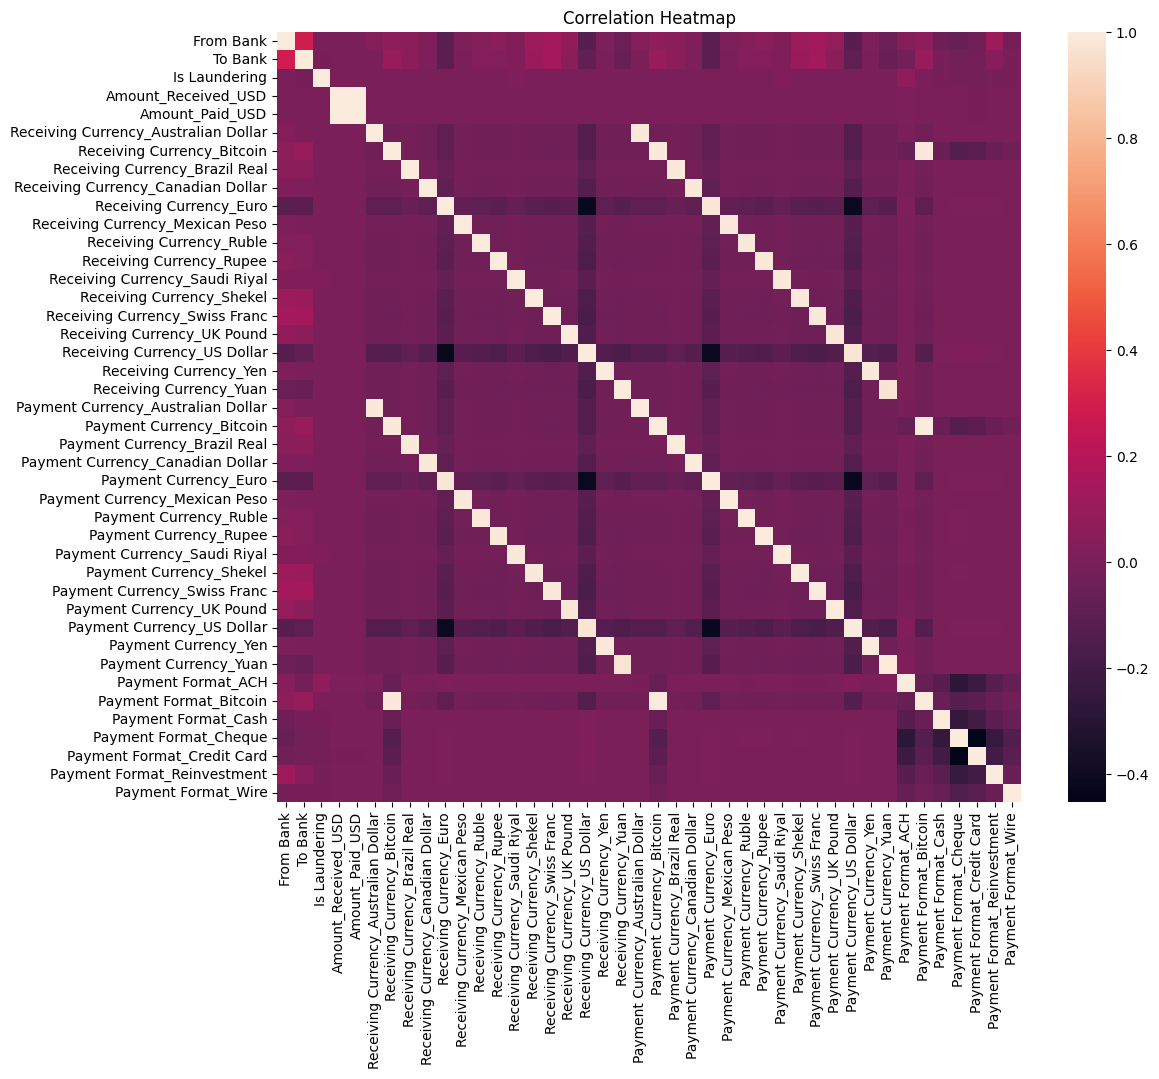

In [112]:
plt.figure(figsize=(12, 10)) # Adjust the width and height as needed
sns.heatmap(hi_small_trans_cleaned_df.corr(numeric_only=True))
plt.title("Correlation Heatmap")
plt.savefig("ibm_figs/correlation.png")

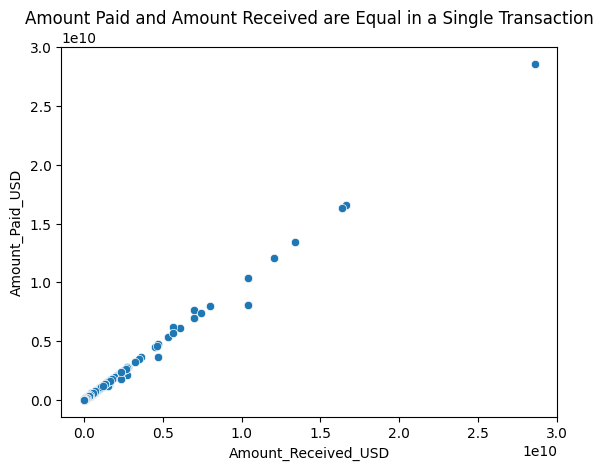

In [38]:
# We can see that the currency conversion roughly worked. There a couple transactions that were close to perfect conversion but the rate could have been slighttly off
sns.scatterplot(x=hi_small_trans_df['Amount_Received_USD'], y=hi_small_trans_df['Amount_Paid_USD'])
plt.title("Amount Paid and Amount Received are Equal in a Single Transaction")
None

## Timeline of Transactions for a Sample Account

In [39]:
# Plotting a timeline of transactions that contains money laundering
hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1]

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
4742,2022/09/01 00:21,70,100428660,1124,800825340,US Dollar,US Dollar,Cheque,1,3.897694e+05,3.897694e+05
40621,2022/09/01 00:03,70,100428660,11474,805B716C0,US Dollar,US Dollar,Credit Card,1,2.902433e+04,2.902433e+04
69152,2022/09/01 00:01,70,100428660,15980,80B39E7B0,US Dollar,US Dollar,Credit Card,1,7.929200e+02,7.929200e+02
85763,2022/09/01 00:03,70,100428660,113798,80DC756E0,US Dollar,US Dollar,Cheque,1,1.317143e+07,1.317143e+07
90684,2022/09/01 00:23,70,100428660,32375,80E480620,US Dollar,US Dollar,Cash,1,1.428883e+04,1.428883e+04
...,...,...,...,...,...,...,...,...,...,...,...
5071168,2022/09/10 23:29,111433,8065C2380,21550,8065C69E0,US Dollar,US Dollar,ACH,1,7.773420e+03,7.773420e+03
5073375,2022/09/10 23:07,9,80727F930,219557,8072A28C0,Ruble,Ruble,Cheque,1,7.452083e+03,7.452083e+03
5074248,2022/09/12 03:34,222,812D127D0,50202,812D129C0,Saudi Riyal,Saudi Riyal,ACH,1,5.342799e+03,5.342799e+03
5075056,2022/09/10 23:43,17327,8095F6C20,15695,8095F6C70,US Dollar,US Dollar,ACH,1,3.314360e+03,3.314360e+03


C:\Users\caleb\AppData\Local\Temp\ipykernel_16812\2168068838.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hi_transactions_sample['Timestamp_Date'] = pd.to_datetime(hi_transactions_sample['Timestamp'])


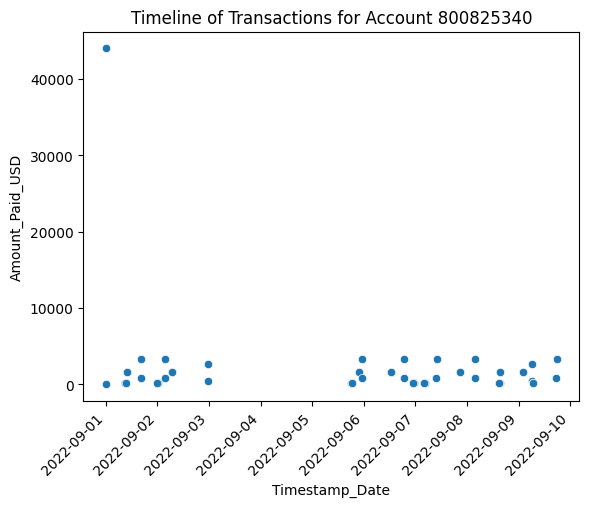

In [40]:
hi_transactions_sample = hi_small_trans_df[hi_small_trans_df['Account'] == '800825340']
hi_transactions_sample['Timestamp_Date'] = pd.to_datetime(hi_transactions_sample['Timestamp'])
sns.scatterplot(hi_transactions_sample, x="Timestamp_Date", y="Amount_Paid_USD")
plt.xticks(rotation=45, horizontalalignment='right')
plt.title("Timeline of Transactions for Account 800825340")
None

## Bivariate Analysis

In [41]:
hi_small_trans_df

,Timestamp,From Bank,Account,To Bank,Account.1,Receiving Currency,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,US Dollar,US Dollar,Reinvestment,0,3697.340000,3697.340000
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,US Dollar,US Dollar,Cheque,0,0.010000,0.010000
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,US Dollar,US Dollar,Reinvestment,0,14675.570000,14675.570000
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,US Dollar,US Dollar,Reinvestment,0,2806.970000,2806.970000
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,US Dollar,US Dollar,Reinvestment,0,36682.970000,36682.970000
...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,3107.386389,3107.386389
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,2168.020464,2168.020464
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,100.011894,100.011894
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,Bitcoin,Bitcoin,Bitcoin,0,770.280058,770.280058


In [42]:
hi_small_trans_sample_df = hi_small_trans_df.sample(10_000)

#### Histogram of Amount Paid Colored by Payment Format

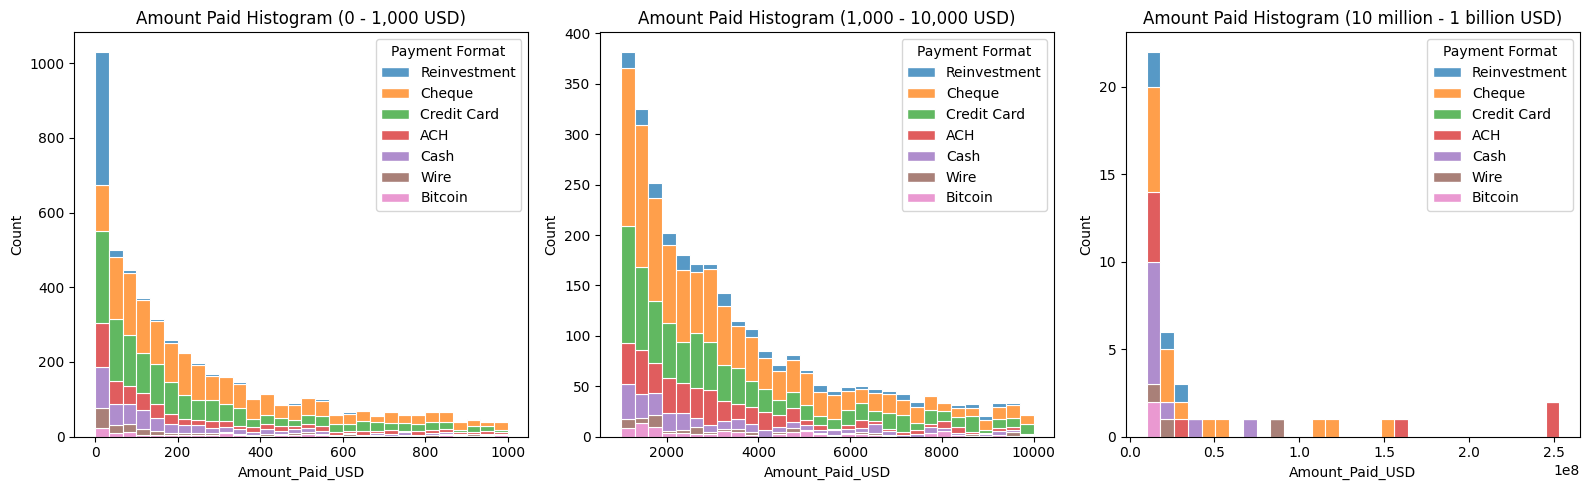

In [82]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
payment_order = hi_small_trans_df['Payment Format'].unique().tolist()
# Common parameters for readability
params = {
    "hue": "Payment Format",
    "bins": 30,
    # "palette": "viridis",  # High-contrast, colorblind-friendly palette
    "multiple": "stack",   # Prevents colors from blending in overlapping areas
    "edgecolor": "white",   # Adds definition between bars
    "hue_order": payment_order
}

sns.histplot(data=hi_small_trans_sample_df[hi_small_trans_sample_df['Amount_Paid_USD'].between(0, 1_000)], x="Amount_Paid_USD", ax=ax1, **params)
ax1.set_title("Amount Paid Histogram (0 - 1,000 USD)")
sns.histplot(data=hi_small_trans_sample_df[hi_small_trans_sample_df['Amount_Paid_USD'].between(1_000, 10_000)], x="Amount_Paid_USD", ax=ax2, **params)
ax2.set_title("Amount Paid Histogram (1,000 - 10,000 USD)")
sns.histplot(data=hi_small_trans_sample_df[hi_small_trans_sample_df['Amount_Paid_USD'].between(10_000_000, 1_000_000_000)], x="Amount_Paid_USD", ax=ax3, **params)
ax3.set_title("Amount Paid Histogram (10 million - 1 billion USD)")

plt.tight_layout()
plt.savefig("ibm_figs/amount_paid_hist.png")

#### Payment Format by Fraud

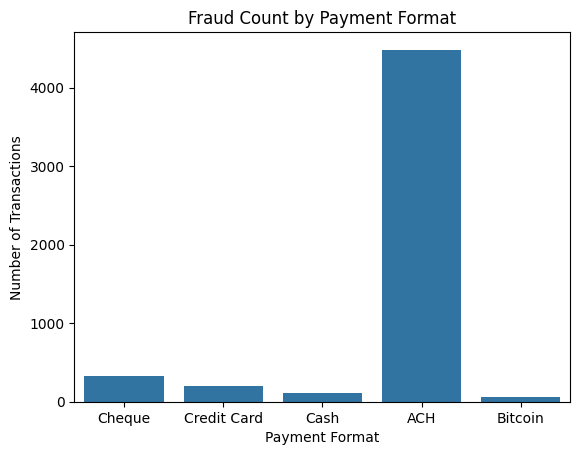

In [110]:
sns.countplot(hi_small_trans_df[hi_small_trans_df['Is Laundering'] == 1], x='Payment Format', hue='Is Laundering')
plt.title('Fraud Count by Payment Format')
plt.xlabel('Payment Format')
plt.ylabel('Number of Transactions')
plt.gca().get_legend().remove()
plt.savefig("ibm_figs/fraud_count_by_payment_format.png")

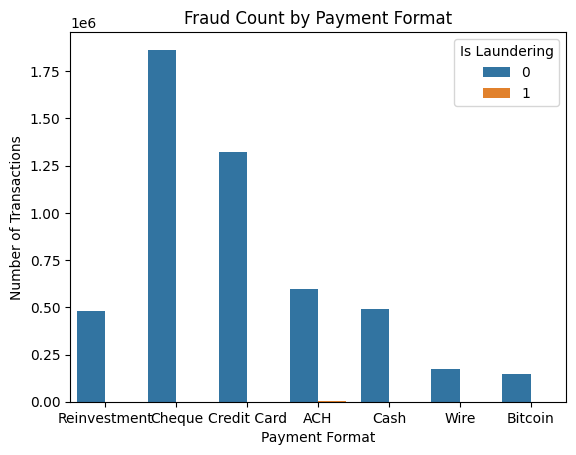

In [44]:
sns.countplot(hi_small_trans_df, x='Payment Format', hue='Is Laundering')
plt.title('Fraud Count by Payment Format')
plt.xlabel('Payment Format')
plt.ylabel('Number of Transactions')
plt.show()

## Conclusions

The IBM synthetic accounts/transactions dataset is high quality. There are no missing values to handle. There are some duplicates instances, but none that we need to drop. Additionally, there are a large number of instances we can use for analysis.

In the boxplots, we can see some outliers for the Amount Recieved/Paid features. The outliers are for large amounts. The majority of transactions are for small sums

The Amount Received/Paid features are highly correlated. This is because they are equal and opposite to each other. Having the duplicate information will be useful for building the full relationship of transactions for a given account

Looking at a sample account which had fraudulent transaction, we see a number of smaller transactions and single large transaction. One strategy that a fraudster might utilize is spending a large sum from an account they have taken over. This does not cover all possible methods though. More in depth analysis will be needed to uncover these patterns.

The largest challenge with this dataset is that feature engineering is required before analysis. There is only a small number of features. The real insights into fraud will come from building up a full picture of the transactions for each account. From here the model can learn what types of transactions are dissimilar to normal ones. One strategy I will employ is creating an engineered feature to represent the average purchase amount for an account, as well as the amount of times two accounts have sent money to each other.